# Approximating double n-capture

We want to approximate the sequence $A(n,\gamma)X(n,\gamma)B$ as $A(nn,\gamma)B$ by combining the two successive neutron captures into a single rate, assuming equilibrium of nucleus $X$.

This type of approximation is commonly done in the "aprox" family of networks, for example, approximating the sequence:
${}^{52}\mathrm{Fe}(n,\gamma){}^{53}\mathrm{Fe}(n,\gamma){}^{54}\mathrm{Fe}$.

In [1]:
import pynucastro as pyna

## Unapproximated version

We'll create a simple network of iron isotopes linked by neutron capture.

In [2]:
rl = pyna.ReacLibLibrary()
lib = rl.linking_nuclei(["fe52", "fe53", "fe54", "n"])

In [3]:
net = pyna.PythonNetwork(libraries=[lib])

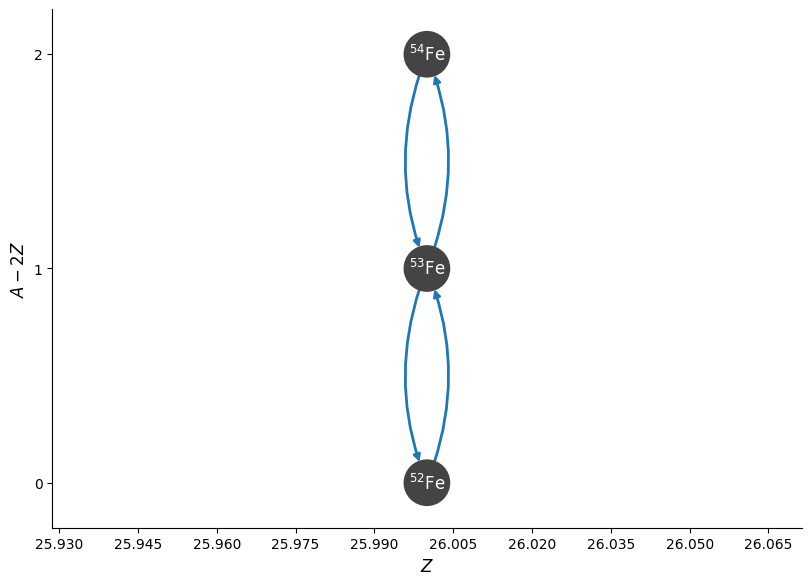

In [4]:
fig = net.plot(rotated=True, curved_edges=True)

Now we'll integrate it, starting with a mix of ${}^{52}\mathrm{Fe}$ and $n$.

In [5]:
rho = 1.e9
T = 3.e9
comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("n")] = 0.5
comp.X[pyna.Nucleus("Fe52")] = 0.5
Y0 = comp.get_molar_array()

In [6]:
tmax = 1.e-11

In [7]:
sol = net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6, atol=1.e-8)

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


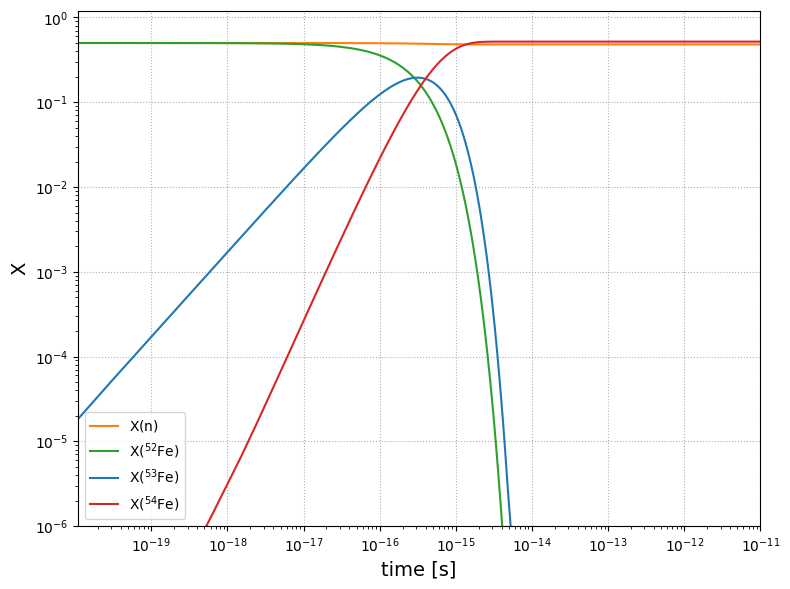

In [8]:
fig = sol.plot_evolution(ymin=1.e-6)

We see that the long term evolution is that all the iron winds up as ${}^{54}\mathrm{Fe}$.

## Approximating the double n capture

We can use the helper function `create_double_neutron_capture()` to create a pair (forward and reverse) of `ApproximateRates` that approximate out the intermediate nucleus:

In [9]:
rf, rr = pyna.rates.create_double_neutron_capture(rl, pyna.Nucleus("fe52"), pyna.Nucleus("fe54"))

In [10]:
rf

Fe52 + n + n ⟶ Fe54 + 𝛾

We can see what rates this carries internally:

In [11]:
rf.hidden_rates

[Fe52 + n ⟶ Fe53 + 𝛾, Fe53 + n ⟶ Fe54 + 𝛾, Fe54 ⟶ n + Fe53, Fe53 ⟶ n + Fe52]

```{tip}
Alternately, we could use the `make_nn_g_approx()` method on the `PythonNetwork` once we create it.
```

Now we'll build a new network with just these approximate rates:

In [12]:
net_approx = pyna.PythonNetwork(rates=[rf, rr])

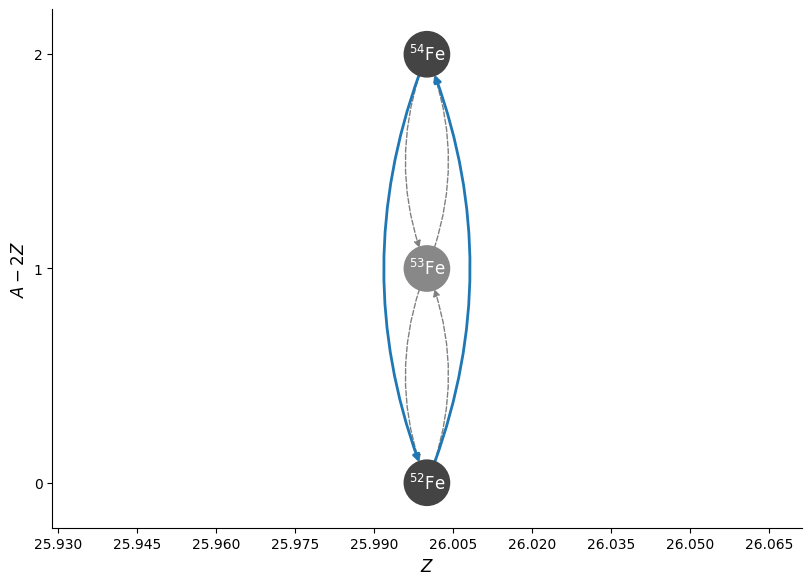

In [13]:
fig = net_approx.plot(rotated=True, curved_edges=True)

In [14]:
comp = pyna.Composition(net_approx.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("n")] = 0.5
comp.X[pyna.Nucleus("Fe52")] = 0.5
Y0 = comp.get_molar_array()

In [15]:
sol_approx = net_approx.integrate_network(tmax, rho, T, Y0, rtol=1.e-6, atol=1.e-8)

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


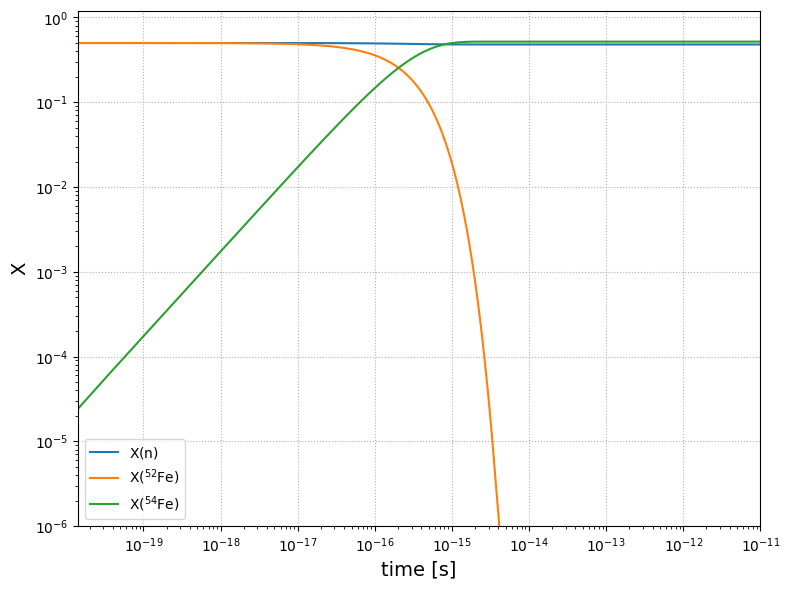

In [16]:
fig = sol_approx.plot_evolution(ymin=1.e-6)

## Comparison

Finally, let's plot the nuclei in common from both nets together

In [17]:
import matplotlib.pyplot as plt

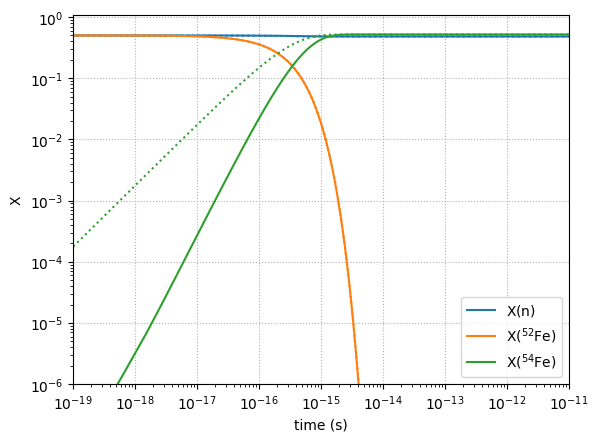

In [18]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_approx.unique_nuclei):
    ax.loglog(sol_approx.t, sol_approx.X[i, :],
              linestyle=":", color=f"C{i}")    
    idx = sol.unique_nuclei.index(nuc)
    ax.loglog(sol.t, sol.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-19, 1.e-11)
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend()
ax.grid(ls=":")

Here the dotted line is the approximate version.  We see that the ${}^{52}\mathrm{Fe}$ is consumed at the same rate.  The approximate net produces ${}^{54}\mathrm{Fe}$ faster simply because there is no intermediate ${}^{53}\mathrm{Fe}$ in the network.